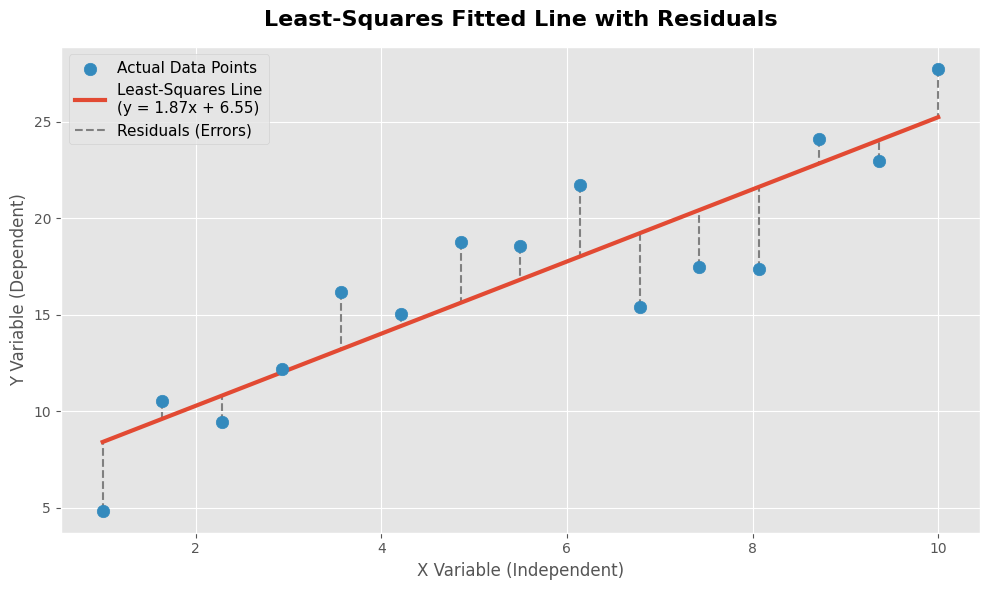

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set ggplot style for aesthetics
plt.style.use('ggplot')


# 1. GENERATE MOCK DATA
np.random.seed(13)
x = np.linspace(1, 10, 15)
# Create y values with a linear trend (y = 2x + 5) plus some random noise
y = 2 * x + 5 + np.random.normal(0, 3, 15) 

# 2. CALCULATE THE LEAST-SQUARES LINE
# np.polyfit(x, y, 1) fits a 1st-degree polynomial (a straight line)
# It returns the slope (m) and intercept (c) that minimize the squared errors
m, c = np.polyfit(x, y, 1)

# Calculate the predicted y values based on the fitted line
y_pred = m * x + c


# 3. VISUALIZATION
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the actual data points
ax.scatter(x, y, color='#348ABD', s=80, label='Actual Data Points', zorder=3)

# Plot the Least-Squares fitted line
ax.plot(x, y_pred, color='#E24A33', linewidth=3, 
        label=f'Least-Squares Line\n(y = {m:.2f}x + {c:.2f})', zorder=2)

# Plot the Residuals (the vertical distances that are being squared and minimized)
# We draw a line from the actual y to the predicted y for every point
for i in range(len(x)):
    # Only add label for the first line to avoid legend duplication
    label = 'Residuals (Errors)' if i == 0 else ""
    ax.plot([x[i], x[i]], [y[i], y_pred[i]], color='gray', linestyle='--', 
            linewidth=1.5, zorder=1, label=label)

# Add English titles and labels
ax.set_title('Least-Squares Fitted Line with Residuals', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('X Variable (Independent)', fontsize=12)
ax.set_ylabel('Y Variable (Dependent)', fontsize=12)

# Customize the legend
ax.legend(fontsize=11, loc='upper left')

# Adjust layout and display
plt.tight_layout()
plt.show()

Equation: Price = 53164 + (150 * Size) + (-2144 * Age)


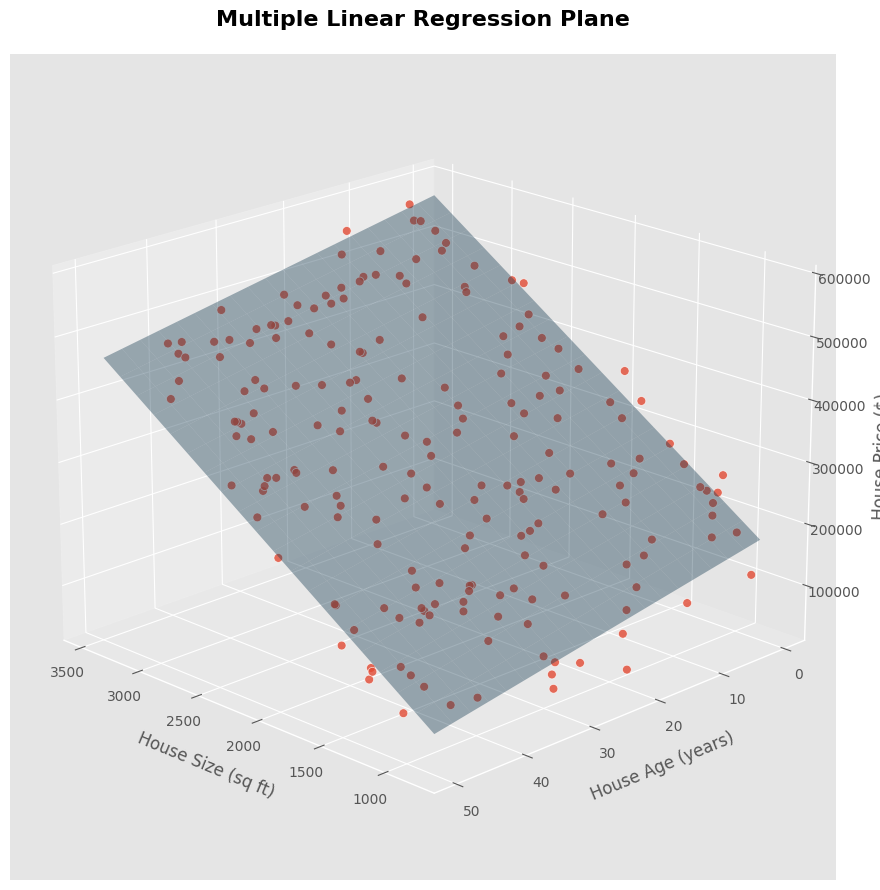

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Set ggplot style for 2D elements (backgrounds, etc.)
plt.style.use('ggplot')

# 1. GENERATE MOCK DATA
np.random.seed(42)
n_samples = 200

# Independent Variable 1: House Size in square feet
house_size = np.random.uniform(800, 3500, n_samples)

# Independent Variable 2: Age of the House in years
house_age = np.random.uniform(0, 50, n_samples)

# Dependent Variable: House Price
# Price increases with size, but decreases with age. Plus some random noise.
base_price = 50000
price = (base_price 
         + (150 * house_size)       # +$150 for every sq ft
         - (2000 * house_age)       # -$2000 for every year of age
         + np.random.normal(0, 40000, n_samples)) # Random market noise

df = pd.DataFrame({'Size': house_size, 'Age': house_age, 'Price': price})

# 2. FIT THE MULTIPLE LINEAR REGRESSION MODEL
X = df[['Size', 'Age']]
y = df['Price']

model = LinearRegression()
model.fit(X, y)

intercept = model.intercept_
coef_size, coef_age = model.coef_

print(f"Equation: Price = {intercept:.0f} + ({coef_size:.0f} * Size) + ({coef_age:.0f} * Age)")


# 3. VISUALIZATION (3D Scatter + Regression Plane)
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot the actual data points
ax.scatter(df['Size'], df['Age'], df['Price'], color='#E24A33', s=40, alpha=0.8, label='Actual Houses', edgecolor='white')

# Create a meshgrid (a flat surface grid) for the regression plane
x_surf, y_surf = np.meshgrid(np.linspace(df['Size'].min(), df['Size'].max(), 20),
                             np.linspace(df['Age'].min(), df['Age'].max(), 20))

# Calculate predicted prices for the plane using the model equation
z_surf = intercept + (coef_size * x_surf) + (coef_age * y_surf)

# Plot the regression plane
ax.plot_surface(x_surf, y_surf, z_surf, color='#348ABD', alpha=0.4)

# Set English titles and labels
ax.set_title('Multiple Linear Regression Plane', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('\nHouse Size (sq ft)', fontsize=12)
ax.set_ylabel('\nHouse Age (years)', fontsize=12)
ax.set_zlabel('\nHouse Price ($)', fontsize=12)

# Adjust the viewing angle for better visibility
ax.view_init(elev=20, azim=135)

plt.tight_layout()
plt.show()

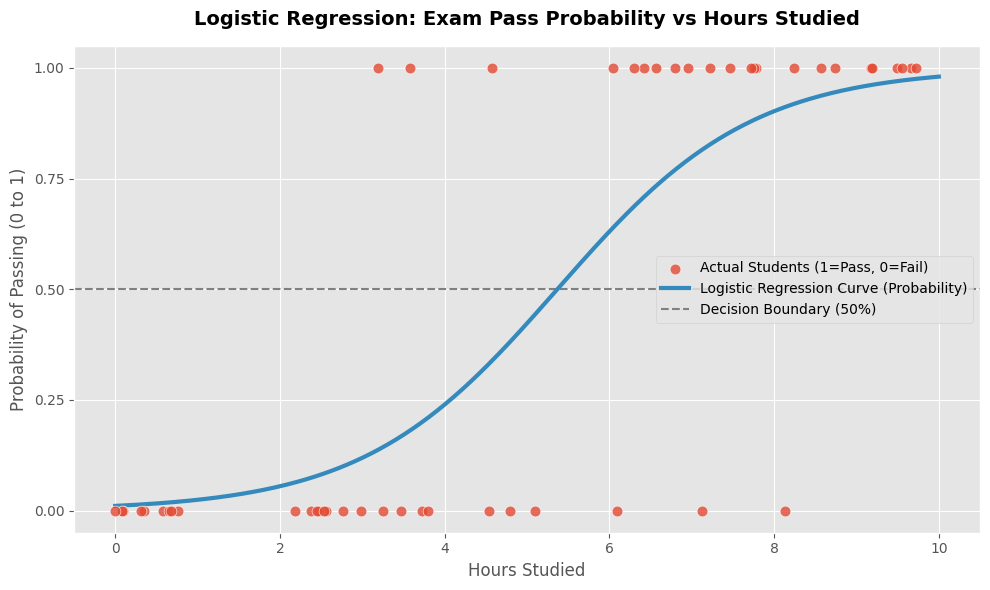

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Set ggplot style for aesthetics
plt.style.use('ggplot')

# 1. GENERATE MOCK DATA (Binary Classification)
np.random.seed(13)
n_students = 50

# X: Hours studied (random values between 0 and 10)
hours_studied = np.random.uniform(0, 10, n_students)

# Y: Did they pass? (1 = Yes, 0 = No)
# We create a hidden probability rule: more hours = higher chance to pass
hidden_probabilities = 1 / (1 + np.exp(-(hours_studied - 5))) 
passed_exam = np.random.binomial(1, hidden_probabilities)

# Reshape X because scikit-learn expects 2D arrays for features
X = hours_studied.reshape(-1, 1)
y = passed_exam


# 2. FIT THE LOGISTIC REGRESSION MODEL
model = LogisticRegression()
model.fit(X, y)


# 3. PREDICT PROBABILITIES FOR A SMOOTH CURVE
# Generate 300 evenly spaced points from 0 to 10 hours for a smooth curve
X_curve = np.linspace(0, 10, 300).reshape(-1, 1)

# predict_proba returns probabilities for both classes [Prob(0), Prob(1)]
# We only want the probability of passing (Class 1), so we take [:, 1]
y_probabilities = model.predict_proba(X_curve)[:, 1]


# 4. VISUALIZATION
plt.figure(figsize=(10, 6))

# Plot the actual student results (either 0 or 1)
plt.scatter(hours_studied, passed_exam, color='#E24A33', s=60, alpha=0.8, 
            edgecolor='white', label='Actual Students (1=Pass, 0=Fail)', zorder=3)

# Plot the S-shaped Logistic Regression curve
plt.plot(X_curve, y_probabilities, color='#348ABD', linewidth=3, 
         label='Logistic Regression Curve (Probability)', zorder=2)

# Add a horizontal line at 0.5 (Decision Boundary)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1.5, 
            label='Decision Boundary (50%)', zorder=1)

# Add English titles and labels
plt.title('Logistic Regression: Exam Pass Probability vs Hours Studied', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hours Studied', fontsize=12)
plt.ylabel('Probability of Passing (0 to 1)', fontsize=12)

# Customize the Y-axis ticks to show clearly it's binary limits
plt.yticks([0, 0.25, 0.5, 0.75, 1.0])

plt.legend(loc='center right', fontsize=10)
plt.tight_layout()

# Show the plot
plt.show()